# Cooperative Coevolution of Predator Robots

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from optim.BSO.bso import bso
from optim.naive.clusterd_naive import naive, clustered_naive
from prey.prey import smartLinear, static, random
from visual.visual import Plot

## Define Testing Grid

In [2]:
grid = 30
Ns = 8
Np = 1
n_prey = 3

## Iteration

All preys caputured with 48 steps


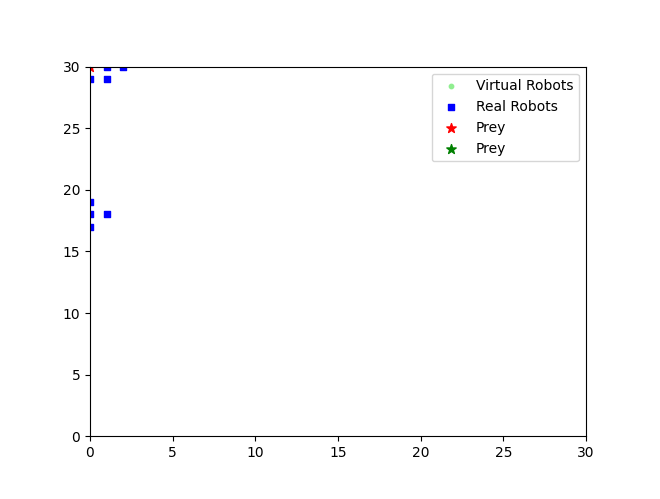

In [3]:
# Define population
p_robots = np.random.randint(0, grid, (Ns, Np, 2))
preys = np.random.randint(0, grid, (n_prey, 2))
captured = np.zeros(n_prey, dtype=np.bool)
plotter = Plot(grid)

T = 150
blocked = False
for t in range(T):
    # Prey move
    preys_copy = preys.copy()
    for p in range(len(preys)):
        # print("p", p)
        target = smartLinear(p_robots[:, 0], preys_copy, p, grid)
        # print("p",p,"ok")
        # result = linear(p_robots[:, 0], preys_copy, p, grid, blocked)
        # if result is not None:
        #     target, blocked = result
        #     preys[p] = target
        # else :
        #     captured[p] = True

        if target is not None:
            preys[p] = target      
        else:
            captured[p] = True 
    # Delete captured preys
    preys = preys[~captured]
    captured = captured[~captured]
    if not len(captured):
        break
    # Robots move
    clustered_naive(p_robots, preys, grid)
    # naive(p_robots, preys, grid)
    plotter.update(p_robots, preys)
    
# Save result
if not len(captured):
    print(f'All preys caputured with {plotter.cnt} steps')
else:
    print(f'Failed to capture all within {plotter.cnt} steps')
plotter.save(file='example.gif', fps=2)

## Batch Test

KeyboardInterrupt: 

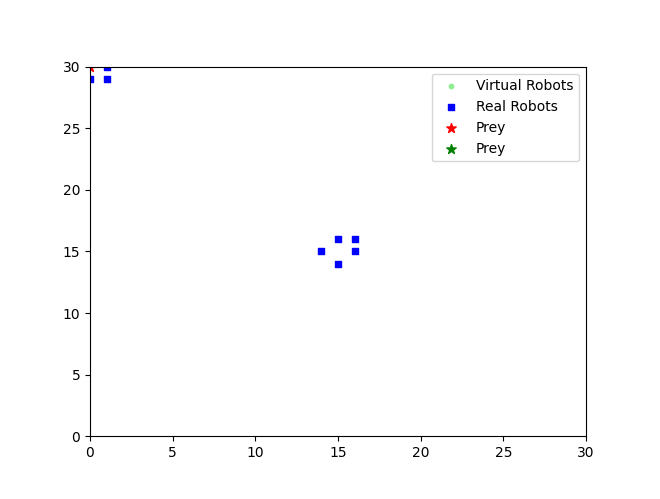

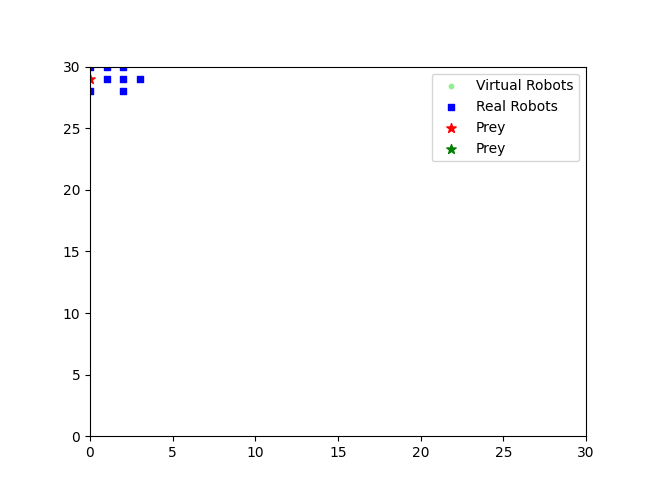

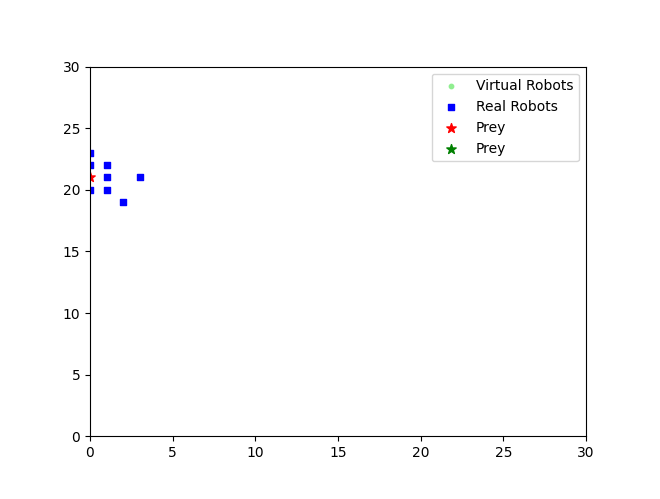

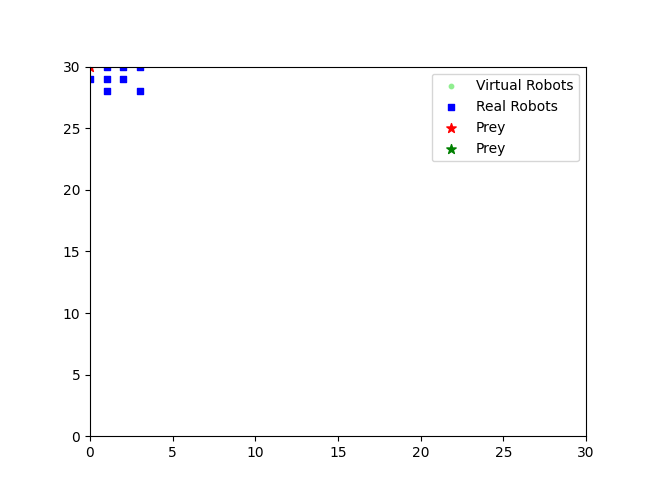

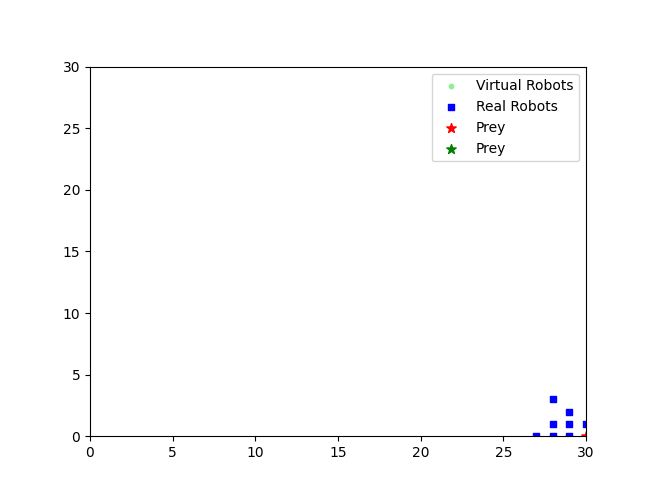

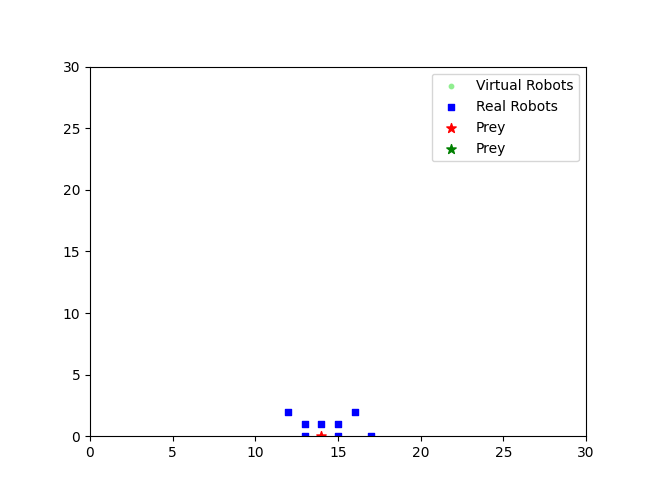

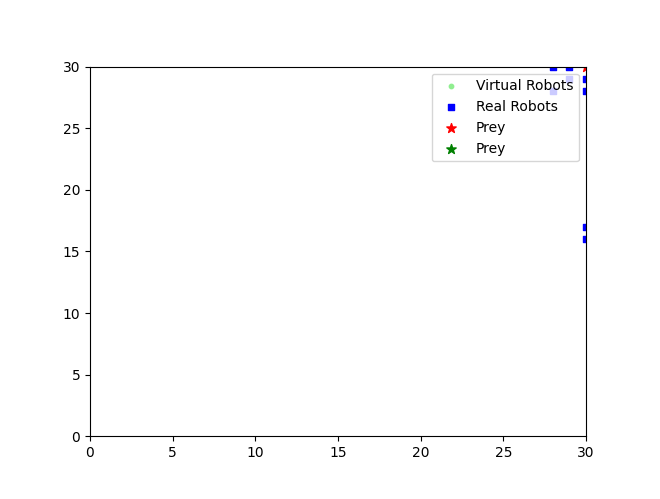

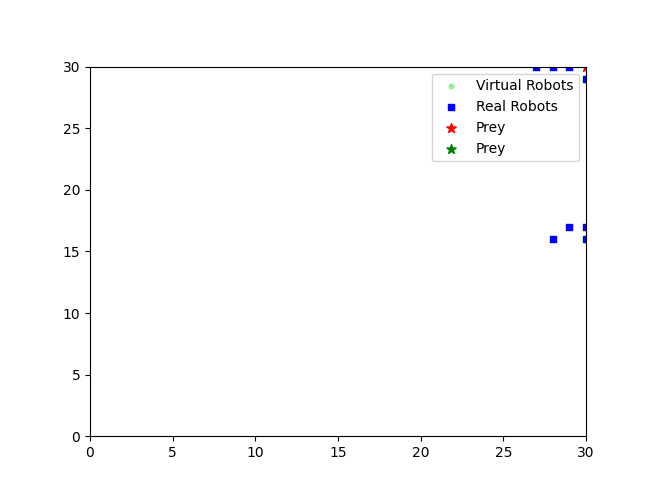

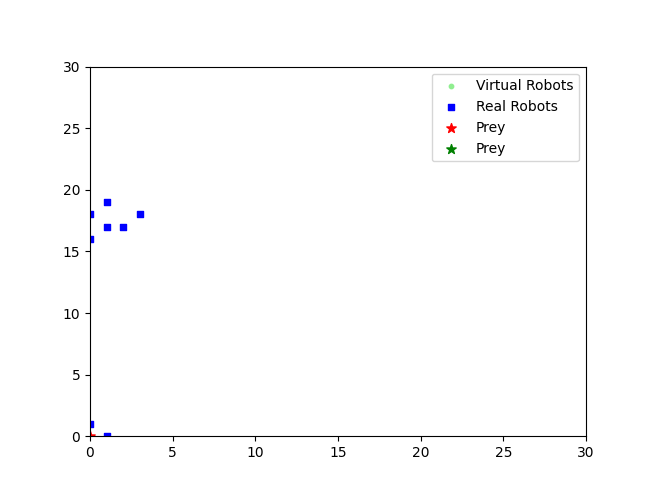

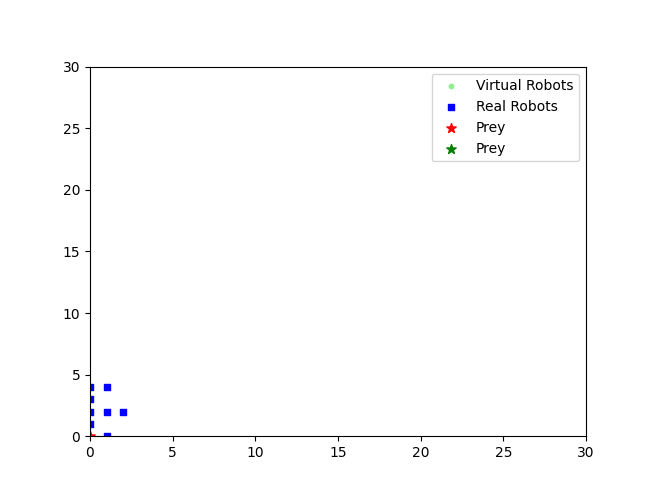

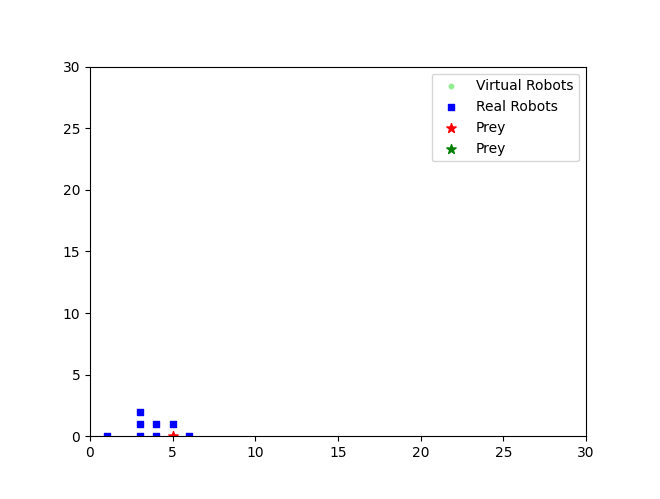

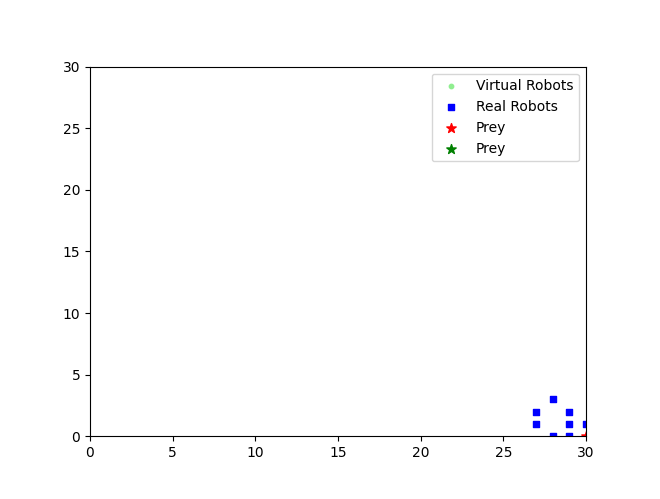

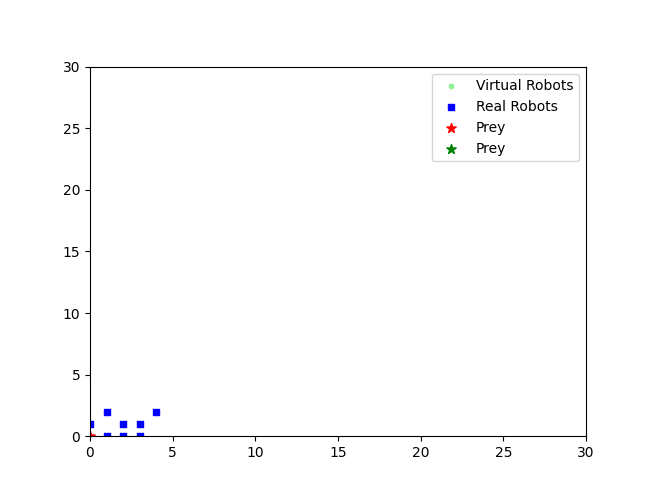

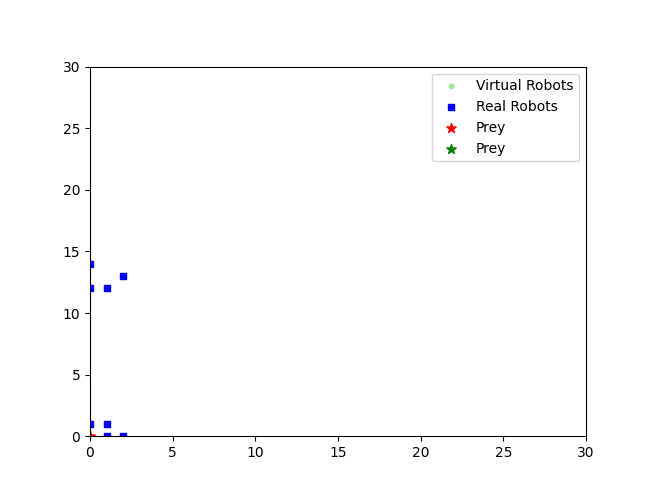

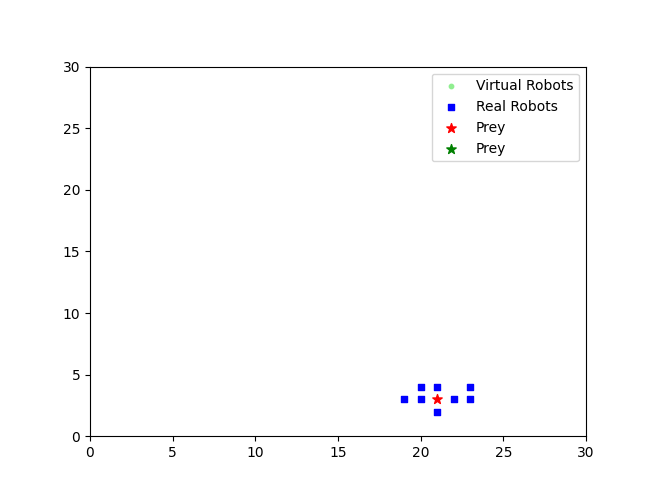

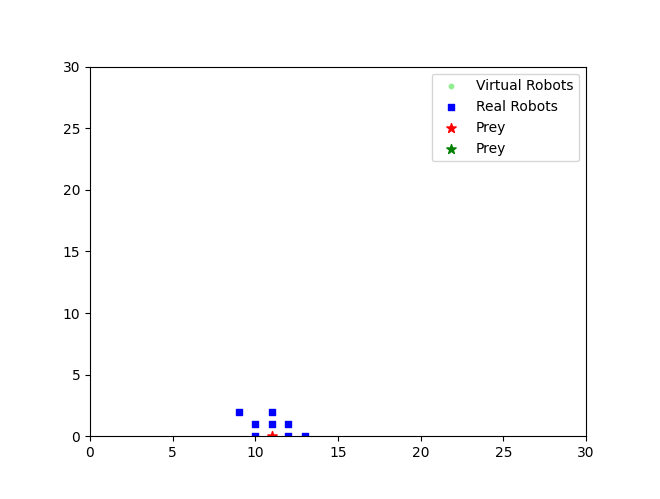

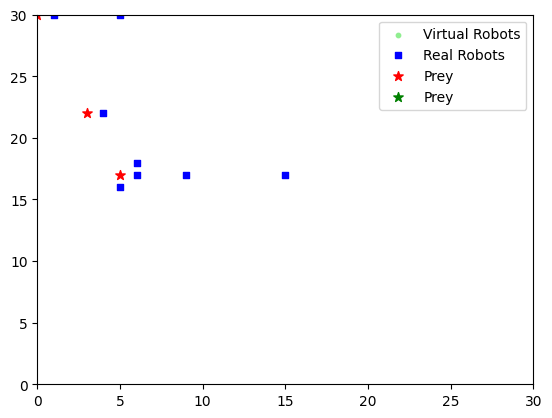

In [4]:
T = 150
batch_size = 30
blocked = False
folder = time.strftime("%Y-%m-%d_%H-%M-%S", time.localtime(time.time()))
os.makedirs(os.path.join('output', folder), exist_ok=True)
with open('output\\'+folder+'\\record.txt', 'w', encoding='utf-8') as file:
    file.write(f'Predators={Ns}, Grid={grid}*{grid}\n')
    for i in range(batch_size):
        p_robots = np.random.randint(0, grid, (Ns, Np, 2))
        preys = np.random.randint(0, grid, (n_prey, 2))
        captured = np.zeros(n_prey, dtype=np.bool)
        plotter = Plot(grid)
        for t in range(T):
            preys_copy = preys.copy()
            for p in range(len(preys)):
                target = smartLinear(p_robots[:, 0], preys_copy, p, grid)
                # target = random(p_robots[:, 0], preys_copy, p, grid)

                if target is not None:
                    preys[p] = target
                else:
                    captured[p] = True
            preys = preys[~captured]
            captured = captured[~captured]
            if not len(captured):
                break
            naive(p_robots, preys, grid)
            # clustered_naive(p_robots, preys, grid)
            plotter.update(p_robots, preys)
        if not len(captured):
            file.write(f'Moves={plotter.cnt}\n')
        else:
            file.write(f'Failed\n')
        plotter.save(file=os.path.join(folder, f'test_{i}.gif'))

## Analysis

Capture Rate: 100.0%
Avg Move: 18.066666666666666
Move Std: 6.840727706578852


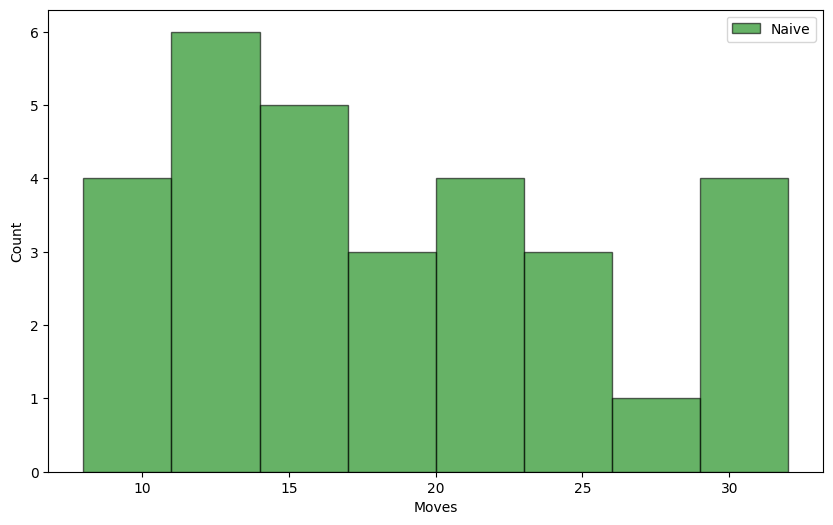

In [ ]:
r = []
success = 0
total = 0
with open('output\\'+folder+'\\record.txt', 'r') as file:
    lines = file.readlines()
for line in lines:
    line = line.strip()
    if line.startswith('Moves'):
        number = line.split('=')[1].strip()
        r.append(int(number))
        success += 1
    total += 1
print(f'Capture Rate: {success / (total - 1) * 100}%')
print(f'Avg Move: {np.mean(r)}')
print(f'Move Std: {np.std(r)}')
plt.figure(figsize=(10, 6))
plt.hist(r, bins=8, alpha=0.6, color='green', label='Naive', edgecolor='black')
plt.xlabel("Moves")
plt.ylabel("Count")
plt.legend()

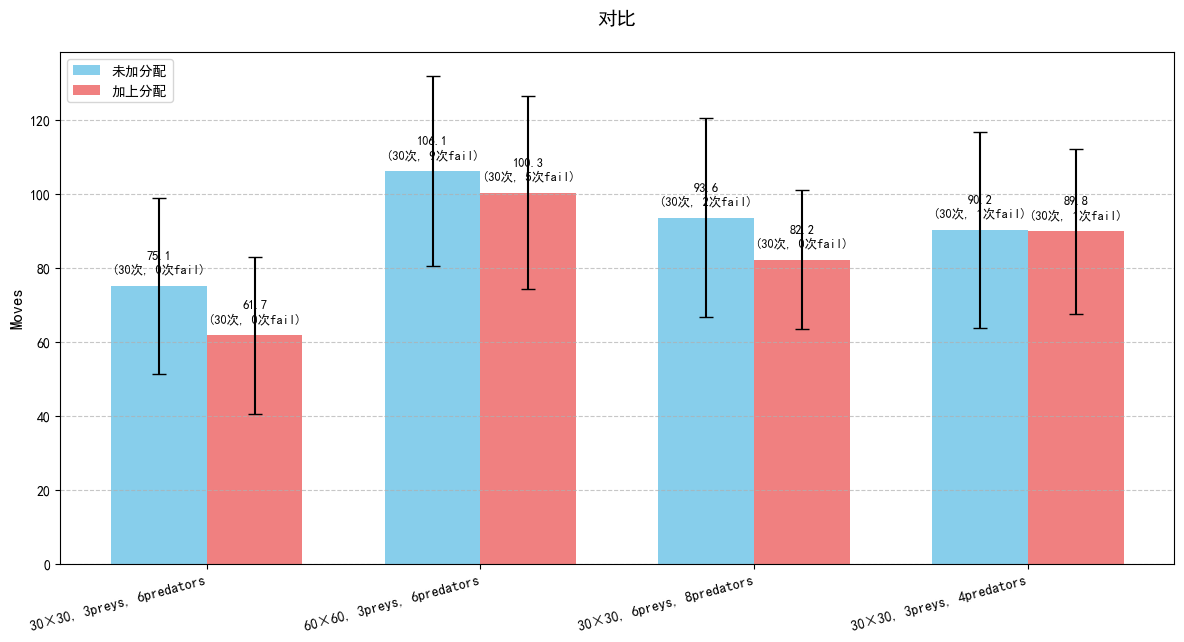

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

conditions = [
    '30×30, 3preys, 6predators', 
    '60×60, 3preys, 6predators',
    '30×30, 6preys, 8predators',
    '30×30, 3preys, 4predators'
]

without_allocation = [75.10, 106.14, 93.57, 90.21]
with_allocation = [61.73, 100.32, 82.20, 89.83]

std_without = [23.88, 25.65, 26.92, 26.49]
std_with = [21.27, 26.06, 18.74, 22.39]

fail_annotations_without = [
    "(30次, 0次fail)", "(30次, 9次fail)",
    "(30次, 2次fail)", "(30次, 1次fail)"
]
fail_annotations_with = [
    "(30次, 0次fail)", "(30次, 5次fail)",
    "(30次, 0次fail)", "(30次, 1次fail)"
]

x = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

# 绘制柱状图（带误差线）
rects1 = ax.bar(
    x - width/2, without_allocation, width, 
    label='未加分配', color='skyblue',
    yerr=std_without, capsize=5, error_kw={'elinewidth': 1.5}
)
rects2 = ax.bar(
    x + width/2, with_allocation, width,
    label='加上分配', color='lightcoral',
    yerr=std_with, capsize=5, error_kw={'elinewidth': 1.5}
)

# 自定义标注函数
def autolabel(rects, annotations):
    for rect, annot in zip(rects, annotations):
        height = rect.get_height()
        ax.annotate(f'{height:.1f}\n{annot}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 8),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9)

# 添加标注
autolabel(rects1, fail_annotations_without)
autolabel(rects2, fail_annotations_with)

# 添加图表元素
ax.set_ylabel('Moves', fontsize=12)
ax.set_title('对比', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(conditions, rotation=15, ha='right')
ax.legend(loc='upper left', fontsize=10)

# 添加网格线
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# 调整布局
plt.tight_layout()
plt.subplots_adjust(top=0.85)

plt.show()

In [ ]:
import os
import numpy as np
from statistics import mean, stdev

base_dir = "output"

all_moves = []

for subdir in os.listdir(base_dir):
    subdir_path = os.path.join(base_dir, subdir)
    if os.path.isdir(subdir_path):
        record_file = os.path.join(subdir_path, "record.txt")
        if os.path.exists(record_file):
            with open(record_file, 'r') as f:
                content = f.read()
                moves_lines = [line for line in content.split('\n') if line.startswith("Moves=")]
                for line in moves_lines:
                    try:
                        moves = int(line.split('=')[1])
                        all_moves.append(moves)
                    except (IndexError, ValueError):
                        continue

if all_moves:
    avg_moves = mean(all_moves)
    std_moves = np.std(all_moves)
    print(f"共找到 {len(all_moves)} 个Moves记录")
    print(f"平均值: {avg_moves:.2f}")
    print(f"标准差: {std_moves:.2f}")
else:
    print("未找到任何Moves记录")

共找到 32 个Moves记录
平均值: 18.69
标准差: 7.56
